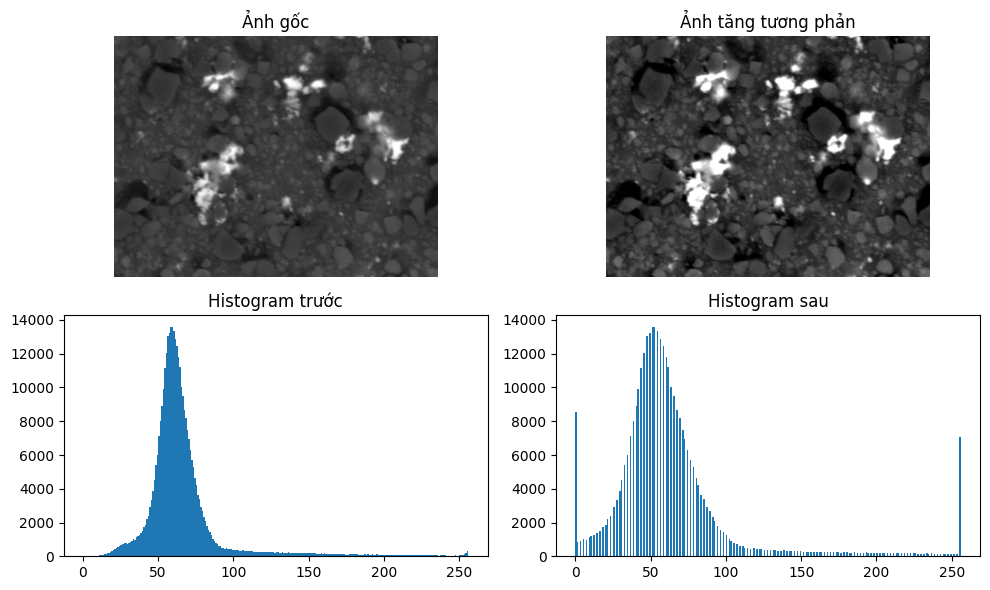

Kích thước ảnh gốc: (515, 692)
Kiểu dữ liệu ảnh gốc: uint8
Giá trị nhỏ nhất/lớn nhất của ảnh gốc: 2 255
Kích thước ảnh sau xử lý: (515, 692)
Kiểu dữ liệu ảnh sau xử lý: uint8
Giá trị nhỏ nhất/lớn nhất của ảnh sau xử lý: 0 255


In [2]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: KÉO GIÃN TƯƠNG PHẢN ẢNH XÁM
# Chương/Mục liên quan: Chương 4 - Tăng cường chất lượng ảnh
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán kéo giãn tương phản ảnh xám.
# - Giúp người học quan sát sự thay đổi của ảnh và histogram sau khi tăng tương phản.
# - Liên hệ phần code với phép biến đổi mức xám tuyến tính trong giáo trình.

# Sau khi chạy code, người học cần:
# 1. Hiểu được vai trò của hai ngưỡng f_min và f_max.
# 2. Quan sát được histogram của ảnh sau xử lý được trải rộng hơn.
# 3. Hiểu rằng kéo giãn tương phản làm tăng độ phân biệt giữa các vùng sáng tối.

# Input:
# - Dữ liệu đầu vào: ảnh low_contrast.png từ GitHub
# - Kiểu dữ liệu: ảnh xám

# Output:
# - Ảnh gốc
# - Ảnh sau khi kéo giãn tương phản
# - Histogram trước xử lý
# - Histogram sau xử lý

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa phép biến đổi mức xám tuyến tính;
# - Các bước xử lý tương ứng với công thức kéo giãn tương phản;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi f_min và f_max, ảnh đầu ra thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)

# Đọc ảnh từ kho GitHub
image_uri = "https://github.com/lthavnu/cv-book/raw/main/images/low_contrast.png"
I = read_gitlab_image(image_uri)

if I is None:
    raise FileNotFoundError("Không tìm thấy file low_contrast.png")

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

# Ảnh đầu vào sẽ được hiển thị cùng với kết quả ở Mục 5

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Thiết lập hai ngưỡng mức xám dùng để kéo giãn tương phản
f_min, f_max = 30, 170

# Công thức kéo giãn tương phản:
# Ie = (I - f_min) / (f_max - f_min) * 255
# Dòng code dưới đây chính là phần minh họa công thức trong giáo trình
Ie = (I.astype(np.float32) - f_min) / (f_max - f_min) * 255

# Giới hạn giá trị điểm ảnh trong miền hợp lệ [0, 255]
Ie = np.clip(Ie, 0, 255).astype(np.uint8)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
plt.imshow(I, cmap='gray')
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(Ie, cmap='gray')
plt.title('Ảnh tăng tương phản')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(I.ravel(), bins=256, range=[0, 256])
plt.title('Histogram trước')

plt.subplot(2, 2, 4)
plt.hist(Ie.ravel(), bins=256, range=[0, 256])
plt.title('Histogram sau')

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Kích thước ảnh gốc:", I.shape)
print("Kiểu dữ liệu ảnh gốc:", I.dtype)
print("Giá trị nhỏ nhất/lớn nhất của ảnh gốc:", I.min(), I.max())

print("Kích thước ảnh sau xử lý:", Ie.shape)
print("Kiểu dữ liệu ảnh sau xử lý:", Ie.dtype)
print("Giá trị nhỏ nhất/lớn nhất của ảnh sau xử lý:", Ie.min(), Ie.max())

assert I.shape == Ie.shape, "Ảnh đầu ra phải có cùng kích thước với ảnh đầu vào"
assert Ie.dtype == np.uint8, "Ảnh đầu ra phải có kiểu uint8"
assert Ie.min() >= 0 and Ie.max() <= 255, "Giá trị điểm ảnh phải nằm trong [0, 255]"

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# Thử thay đổi f_min và f_max, ví dụ:
# - f_min = 20, f_max = 180
# - f_min = 50, f_max = 150
# - f_min = I.min(), f_max = I.max()

# Quan sát:
# - Ảnh sau xử lý sáng hơn hay tối hơn;
# - Histogram sau xử lý có được trải rộng hơn hay không;
# - Khi f_min và f_max chọn quá hẹp, ảnh có thể bị bão hòa sáng hoặc tối.